In [1]:
%%capture
!pip3 install "langchain" "langchain-experimental" "matplotlib" "seaborn" --break-system-packages

In this lab, you will work on the Student Alcohol Consumption data set `student-mat.csv` by UCI Machine Learning as an example. For more information, see [Kaggle](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption). It is based on data collected from two secondary schools in Portugal. The students included in the survey were in mathematics and Portuguese courses.

The dataset you are using is for the mathematics course. The number of mathematics students involved in the collection was 395. The data collected in locations such as Gabriel Pereira and Mousinho da Silveira includes several pertinent values. Examples of such data are records of demographic information, grades, and alcohol consumption.

| Field     | Description                                                                 |
|-----------|-----------------------------------------------------------------------------|
| school    | GP/MS for the student's school                                              |
| sex       | M/F for gender                                                              |
| age       | 15-22 for the student's age                                                 |
| address   | U/R for urban or rural, respectively                                        |
| famsize   | LE3/GT3 for less than or greater than three family members                  |
| Pstatus   | T/A for living together or apart from parents, respectively                 |
| Medu      | 0 (none) / 1 (primary-4th grade) / 2 (5th - 9th grade) / 3 (secondary) / 4 (higher) for mother's education |
| Fedu      | 0 (none) / 1 (primary-4th grade) / 2 (5th - 9th grade) / 3 (secondary) / 4 (higher) for father's education |
| Mjob      | 'teacher,' 'health' care related, civil 'services,' 'at_home' or 'other' for the student's mother's job |
| Fjob      | 'teacher,' 'health' care related, civil 'services,' 'at_home' or 'other' for the student's father's job |
| reason    | reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other') |
| guardian  | mother/father/other as the student's guardian                               |
| traveltime| 1 (<15mins) / 2 (15 - 30 mins) / 3 (30 mins - 1 hr) / 4 (>1hr) for a time from home to school |
| studytime | 1 (<2hrs) / 2 (2 - 5hrs) / 3 (5 - 10hrs) / 4 (>10hrs) for weekly study time |
| failures  | 1-3/4 for the number of class failures (if more than three, then record 4)  |
| schoolsup | yes/no for extra educational support                                        |
| famsup    | yes/no for family educational support                                       |
| paid      | yes/no for extra paid classes for Math or Portuguese                        |
| activities| yes/no for extra-curricular activities                                      |
| nursery   | yes/no for whether attended nursery school                                  |
| higher    | yes/no for the desire to continue studies                                   |
| internet  | yes/no for internet access at home                                          |
| romantic  | yes/no for relationship status                                              |
| famrel    | 1-5 scale on quality of family relationships                                |
| freetime  | 1-5 scale on how much free time after school             |
| goout     | 1-5 scale on how much student goes out with friends      |
| Dalc      | 1-5 scale on how much alcohol consumed on weekdays       |
| Walc      | 1-5 scale on how much alcohol consumed on the weekend    |
| health    | 1-5 scale on health condition                            |
| absences  | 0-93 number of absences from school                      |
| G1        | 0-20 for the first-period grade                          |
| G2        | 0-20 for the second-period grade                         |
| G3        | 0-20 for the final grade                                 |

In [2]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZNoKMJ9rssJn-QbJ49kOzA/student-mat.csv"
)

In [4]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [31]:
df.iloc[0]

school             GP
sex                 F
age                18
address             U
famsize           GT3
Pstatus             A
Medu                4
Fedu                4
Mjob          at_home
Fjob          teacher
reason         course
guardian       mother
traveltime          2
studytime           2
failures            0
schoolsup         yes
famsup             no
paid               no
activities         no
nursery           yes
higher            yes
internet           no
romantic           no
famrel              4
freetime            3
goout               4
Dalc                1
Walc                1
health              3
absences            6
G1                  5
G2                  6
G3                  6
Name: 0, dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [10]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

import os

llm = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="Qwen/Qwen3.5-397B-A17B:novita",
    temperature=0.0,
)

agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose=False,
    return_intermediate_steps=True,
    handle_parsing_errors=True,
    allow_dangerous_code=True,  # required
)

Interacting with the data,

In [11]:
response = agent.invoke("how many rows of data are in this file?")

In [12]:
response['output']

'There are 395 rows of data in this file.'

In [13]:
len(df)

395

In [14]:
response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n')

'len(df)'

In [15]:
response = agent.invoke("Give me all the data where student's age is over 18 years old.")

In [16]:
print(response)

{'input': "Give me all the data where student's age is over 18 years old.", 'output': "I have filtered the dataframe to show all students where age is over 18 years old. The result contains 29 students with the following age distribution:\n- Age 19: 25 students\n- Age 20: 3 students\n- Age 21: 1 student\n- Age 22: 1 student\n\nThe filtered data includes all columns from the original dataframe (school, sex, age, address, famsize, Pstatus, Medu, Fedu, Mjob, Fjob, reason, guardian, traveltime, studytime, failures, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, Dalc, Walc, health, absences, G1, G2, G3) for these 29 students. You can access this filtered data using `df[df['age'] > 18]`.", 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="df[df['age'] > 18]", log="Thought: I need to filter the dataframe to show only rows where the 'age' column is greater than 18. I'll use pandas filtering to accomplish this.\n\nAction:

In [17]:
response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n')

"df[df['age'] > 18]"

### Plot Data with Natural Language

##### Task 1
Generating a first visual on the data set to know the total number of male and female students in the data set.

You just need to tell the agent that "Plot the gender count with bars."

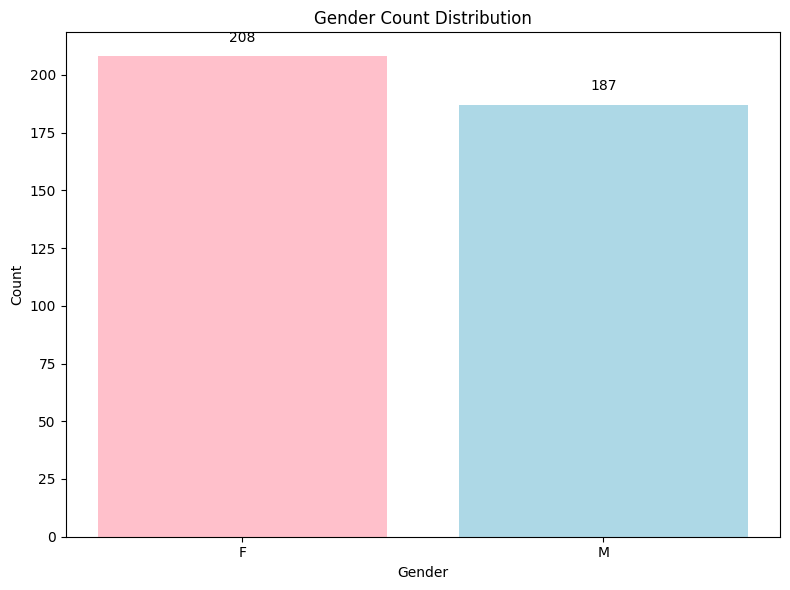

Gender counts:


In [19]:
response = agent.invoke("Generate a bar chart to plot the gender count.")

In [20]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

```python
import matplotlib.pyplot as plt

# Count the gender values
gender_counts = df['sex'].value_counts()

# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(gender_counts.index, gender_counts.values, color=['pink', 'lightblue'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Count Distribution')
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('gender_count_bar_chart.png')
plt.show()

print("Gender counts:")
print(gender_counts)
```


##### Task 2

Generating a pie chart to display the average value of weekend alcohol for each gender in the dataset.

You will use the prompt "Generate a pie chart to display the average value of Walc for each gender."

You may notice that the model generates two charts. The charts indicate the progressive improvement of the agent's code as it searches for the best way to answer your prompt, which improves the response to your query.


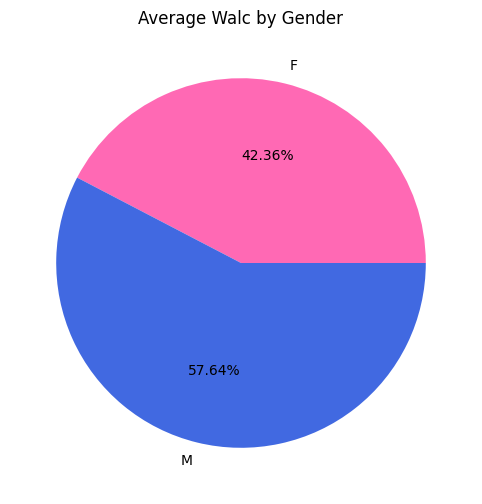

In [21]:
response = agent.invoke("Generate a pie chart to display average value of Walc for each Gender.")

In [22]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

```python
import matplotlib.pyplot as plt

# Group by sex and calculate average Walc
avg_walc_by_sex = df.groupby('sex')['Walc'].mean()

# Create pie chart
plt.figure(figsize=(8, 6))
plt.pie(avg_walc_by_sex.values, labels=avg_walc_by_sex.index, autopct='%1.2f%%', colors=['#FF69B4', '#4169E1'])
plt.title('Average Walc by Gender')
plt.show()
```


##### Task 3

You can explore the impact of free time on grades based on the data.


<Figure size 1000x600 with 0 Axes>

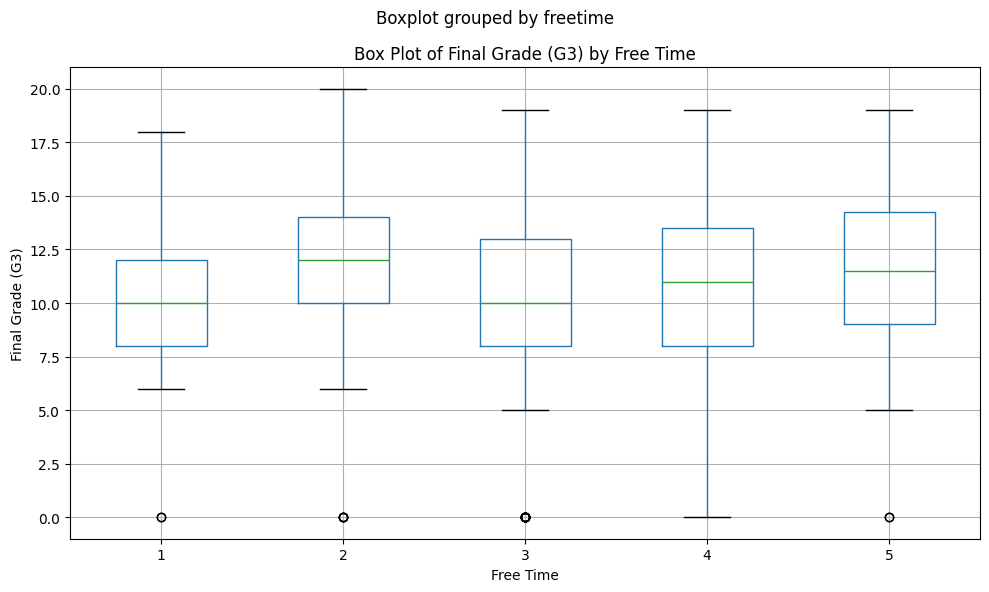

<Figure size 1000x600 with 0 Axes>

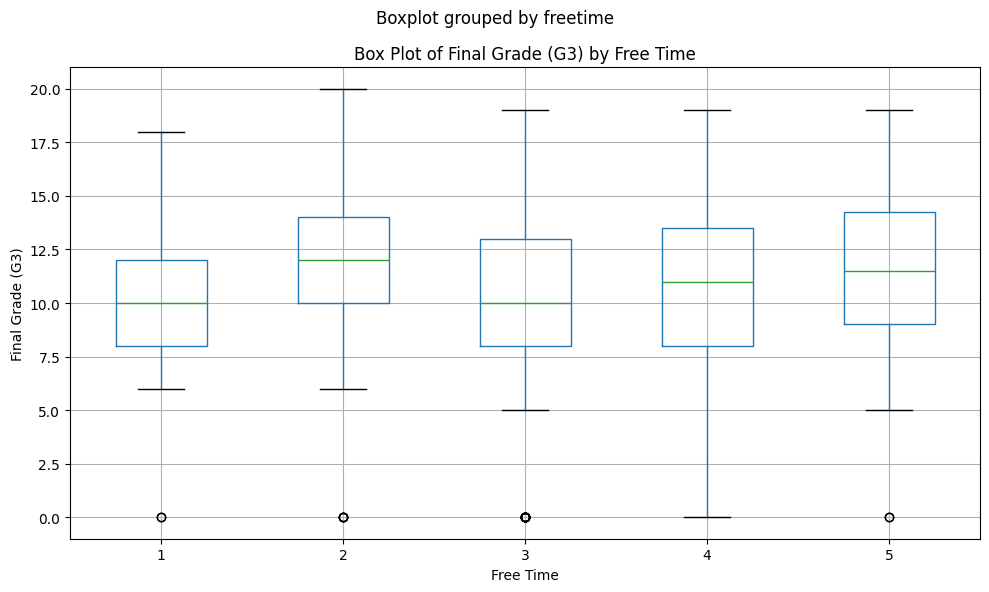

<Figure size 1000x600 with 0 Axes>

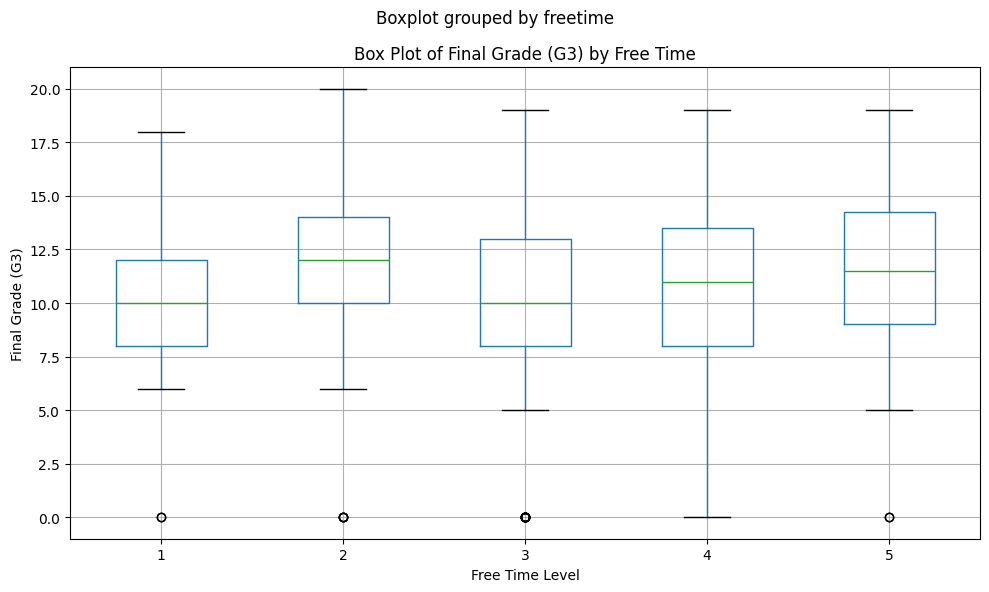

In [23]:
response = agent.invoke("Create box plots to analyze the relationship between 'freetime' (amount of free time) and 'G3' (final grade) across different levels of free time.")

In [24]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

```python
import matplotlib.pyplot as plt

# Create box plot for freetime vs G3
plt.figure(figsize=(10, 6))
df.boxplot(column='G3', by='freetime', figsize=(10, 6))
plt.title('Box Plot of Final Grade (G3) by Free Time')
plt.xlabel('Free Time Level')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('freetime_g3_boxplot.png')
print("Box plot created successfully")
```


##### Task 4

You can explore the effect of alcohol consumption on academic performance.


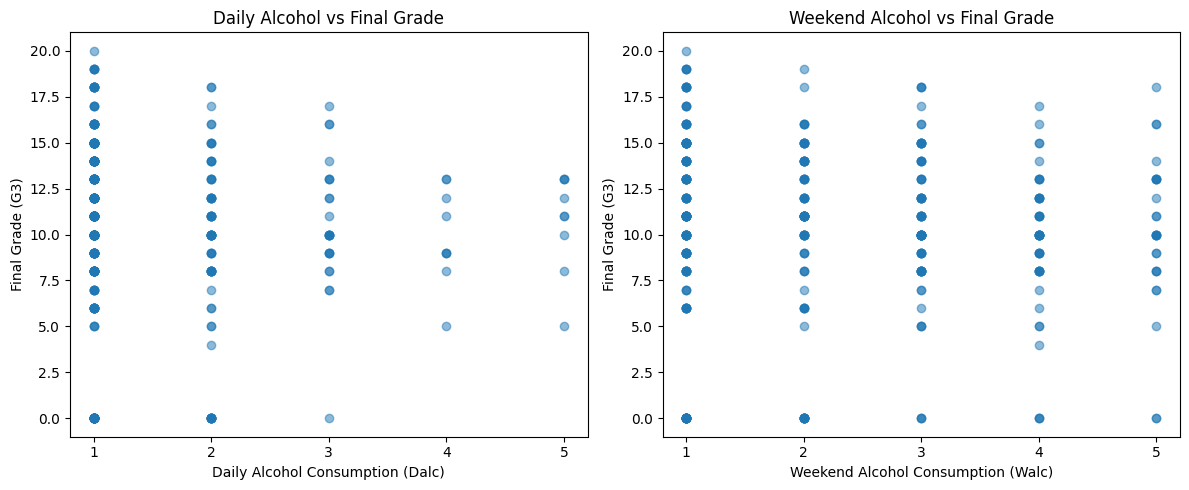

Correlation between Dalc and G3: -0.0547


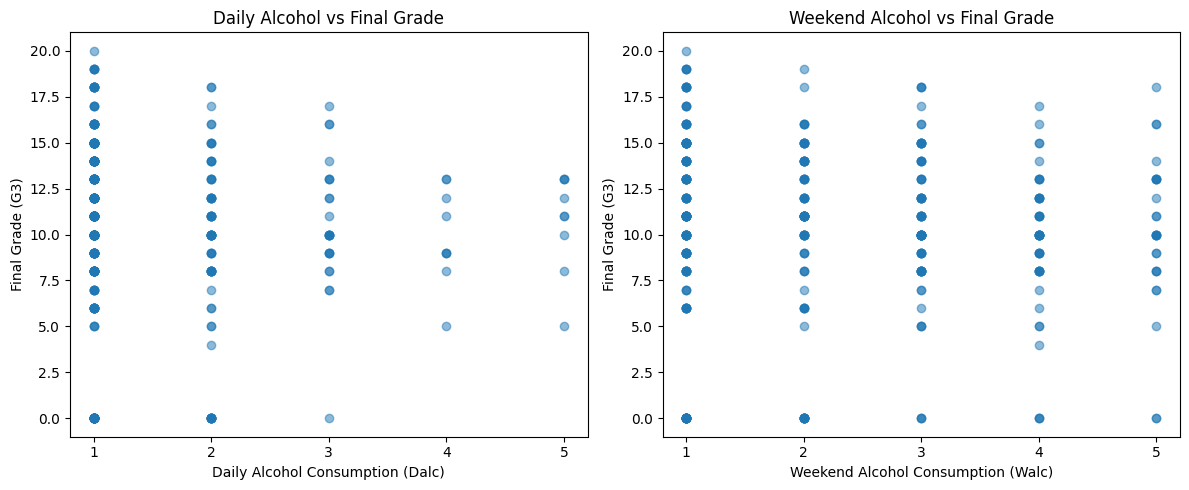

Correlation between Dalc and G3: -0.0547
Correlation between Dalc and G3: -0.0547
Correlation between Dalc and G3: -0.0547


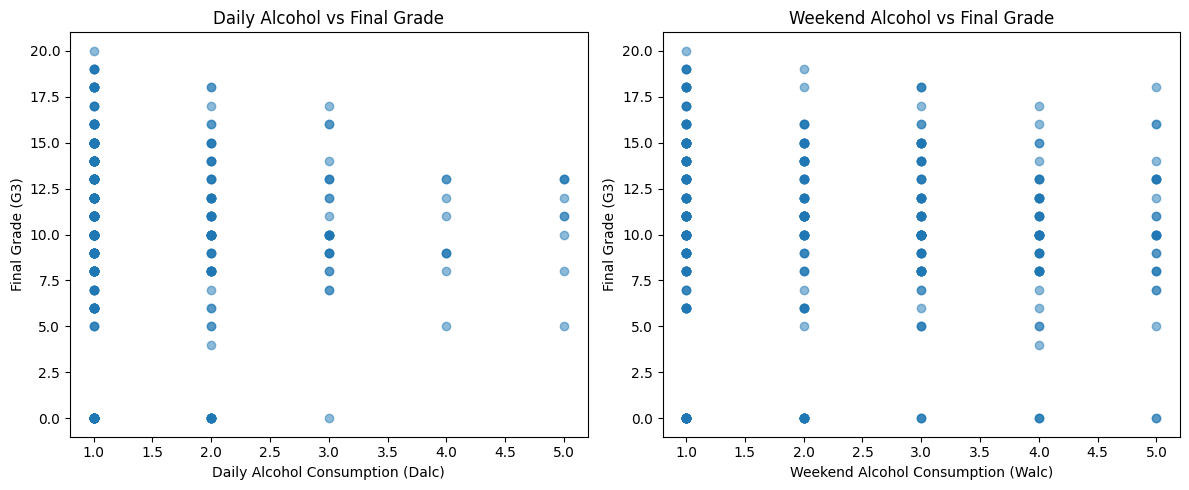

Correlation between Dalc and G3: -0.0547
Correlation between Dalc and G3: -0.0547
Correlation between Dalc and G3: -0.0547
Correlation between Dalc and G3: -0.0547
Correlation between Walc and G3: -0.0519


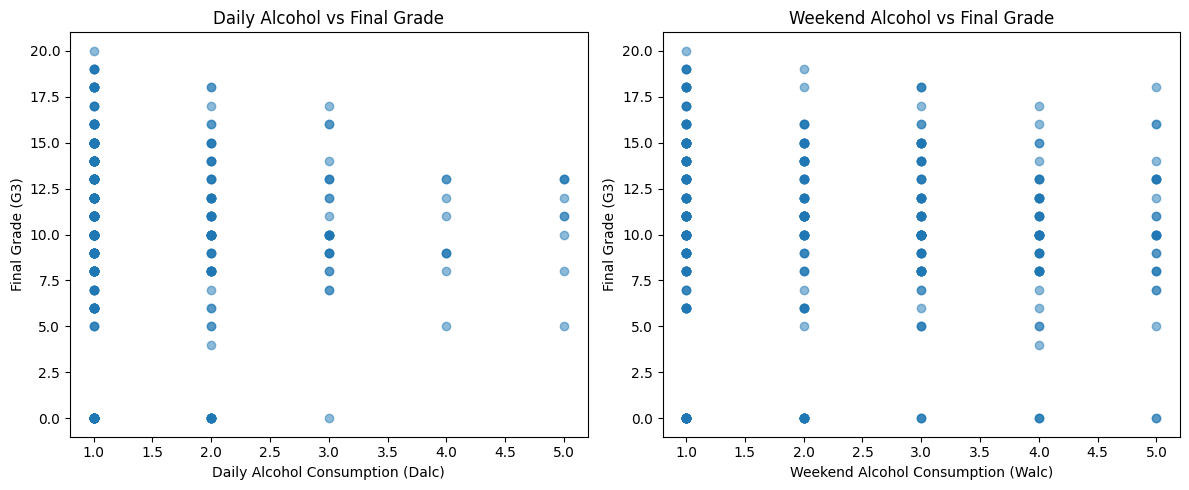

In [25]:
response = agent.invoke("Generate scatter plots to examine the correlation between 'Dalc' (daily alcohol consumption) and 'G3', and between 'Walc' (weekend alcohol consumption) and 'G3'.")

In [26]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

```python
# Calculate correlation coefficients
dalc_corr = df['Dalc'].corr(df['G3'])
walc_corr = df['Walc'].corr(df['G3'])

print(f"Correlation between Dalc and G3: {dalc_corr:.4f}")
print(f"Correlation between Walc and G3: {walc_corr:.4f}")

# Also create the scatter plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['Dalc'], df['G3'], alpha=0.5)
axes[0].set_xlabel('Daily Alcohol Consumption (Dalc)')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].set_title('Daily Alcohol vs Final Grade')

axes[1].scatter(df['Walc'], df['G3'], alpha=0.5)
axes[1].set_xlabel('Weekend Alcohol Consumption (Walc)')
axes[1].set_ylabel('Final Grade (G3)')
axes[1].set_title('Weekend Alcohol vs Final Grade')

plt.tight_layout()
plt.savefig('alcohol_vs_grade_scatter.png')
print("Scatter plots saved to 'alcohol_vs_grade_scatter.png'")
```


### 📝 Exercise 1 - Relationship between parental education level and student grades

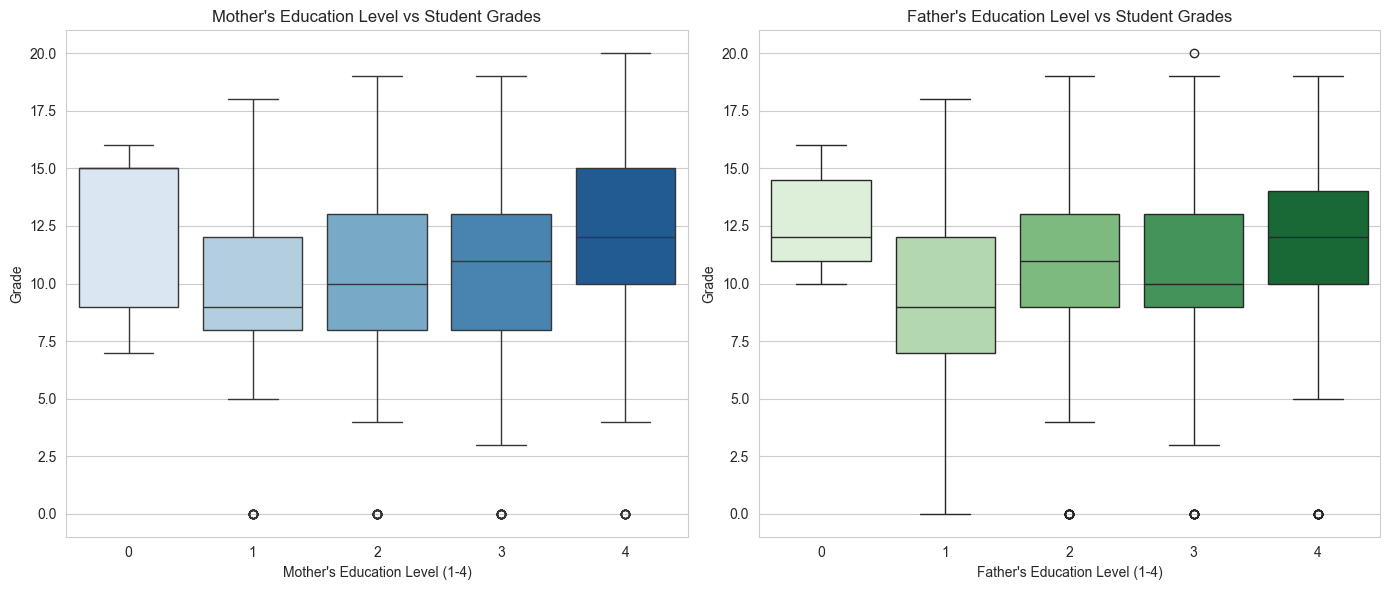

Box plots created successfully!
Data shape after melting: (1185, 4)
Unique Medu values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Summary Statistics by Mother's Education:
             G1         G2         G3
Medu                                 
0     12.000000  12.666667  13.000000
1      9.745763   9.169492   8.677966
2     10.563107  10.359223   9.728155
3     10.606061  10.444444  10.303030
4     11.908397  11.847328  11.763359

Summary Statistics by Father's Education:


In [37]:
# your code here
response = agent.invoke("Create box plots to analyze the relationship between parental education and student grades. Group G1, G2, G3 into a single box plot against each parent education level")

### 📝 Exercise 2 - Impact of internet access at home on grades


Internet access values: ['no' 'yes']

Internet access distribution:
internet
yes    329
no      66
Name: count, dtype: int64

Grade statistics:
Internet access values: ['no' 'yes']

Internet access distribution:
Average grades with internet access: [np.float64(11.015197568389057), np.float64(10.914893617021276), np.float64(10.617021276595745)]
Average grades without internet access: [np.float64(10.378787878787879), np.float64(9.712121212121213), np.float64(9.409090909090908)]


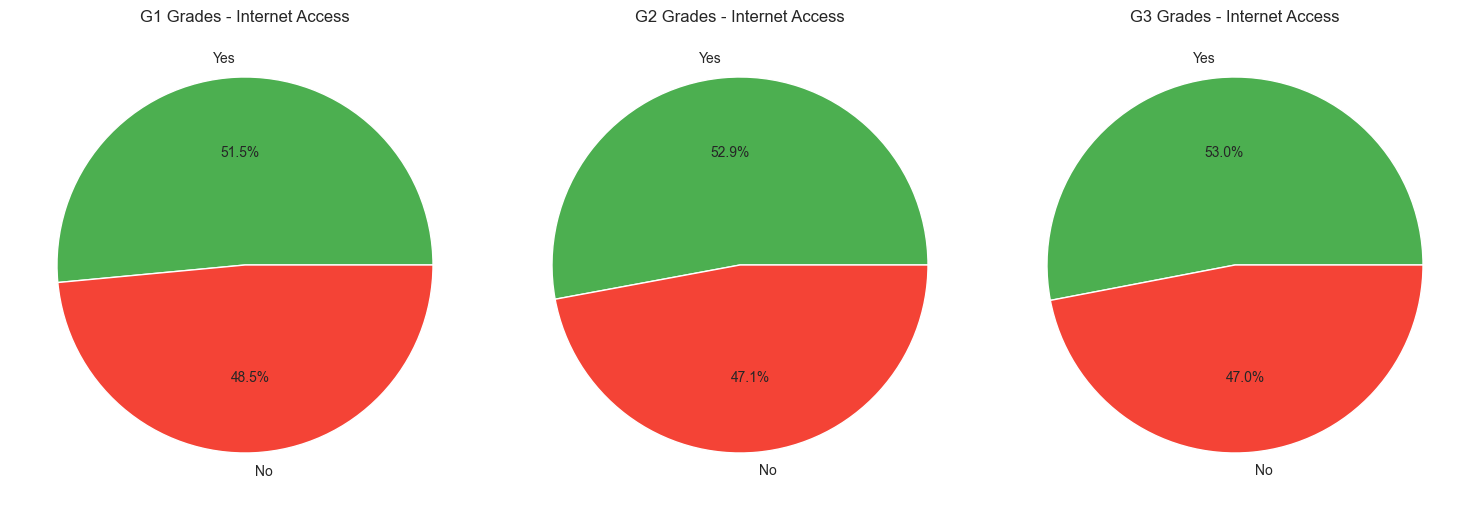

In [38]:
# your code here
response = agent.invoke("Generate piecharts to determine the impact of internet access at home on grades (for G1, G2, G3)")

### 📝 Exercise 3 - Explore LLM's code

Can you find what code the model used to generate the plot for exploring the relationship between absences and academic performance?

You could run the corresponding code and from the response chain, you could see the code used from charting.


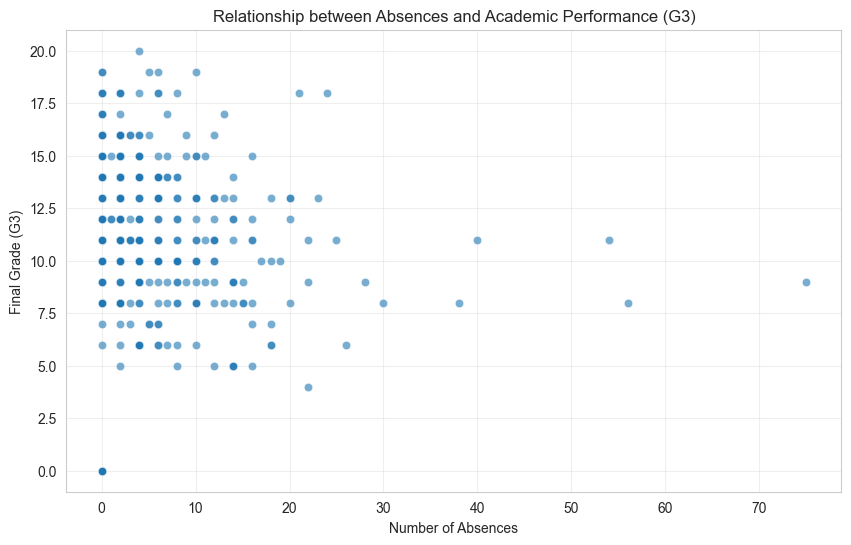

In [40]:
# your code here
response = agent.invoke("generate the appropriate plot for exploring the relationship between absences and academic performance")